In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
LOT-003: Speaker Price Modelling
================================
Pipeline:
1) Load + clean
2) Grouped split by stable product id (spec_general_reference)
3) Target encoding for selected categoricals (train-only stats, smoothed)
4) Train LR / Ridge / RF / XGB
5) Pick best on val, evaluate on test
6) Save encoder + models + metadata
"""

import os
import json
import time
import pickle
from dataclasses import dataclass
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# XGBoost
import xgboost as xgb

# -----------------------------
# Config
# -----------------------------
DATA_PATH = "../Datas/speaker_db_selected_refined.csv"
TARGET_COL = "price"

GROUP_COL = "spec_general_reference"  # stable product id

# Optional hard drops (ids, quasi-ids, very leaky / useless)
DROP_COLS_ALWAYS = [
    "row_id",
    # Keep GROUP_COL for split but drop from features after split:
    # "spec_general_reference",
]

# If you already decided to drop these:
DROP_COLS_OPTIONAL = [
    "spec_dimensions_hauteur_entrefer_mm",
    "spec_donnees_rendement_pct",
    "spec_donnees_ebp_hz",
    "spec_parametres_fondamentaux_re_ohm",
]

# Target encoding columns (adjust to your dataset)
CATEGORICAL_COLS_TE = [
    "spec_general_marque",
    "spec_general_type_produit",
    "spec_forme_materiaux_systeme_magnetique",
    "spec_forme_materiaux_forme_facade",
    "spec_forme_materiaux_materiau_saladier",
    "spec_forme_materiaux_materiau_suspension",
    "spec_forme_materiaux_support_bobine",
    "spec_forme_materiaux_fil_bobine",
    "spec_forme_materiaux_materiau_dome",
    "spec_informations_impedance_nominale",
]

# Numeric columns to keep (if None => autodetect numeric)
NUMERIC_COLS_FORCE = None

# Split ratios by group
TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20
SEED = 42

# Encoder smoothing
TE_K = 20

# Output directories
OUT_DATA_DIR = "../data/processed"
OUT_MODELS_DIR = "./models/trained"
OUT_ENCODERS_DIR = "./models/encoders"
OUT_RESULTS_DIR = "./results"

os.makedirs(OUT_DATA_DIR, exist_ok=True)
os.makedirs(OUT_MODELS_DIR, exist_ok=True)
os.makedirs(OUT_ENCODERS_DIR, exist_ok=True)
os.makedirs(OUT_RESULTS_DIR, exist_ok=True)


# -----------------------------
# Utilities
# -----------------------------
def evaluate(y_true, y_pred, name="Model"):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    print(f"\n{name}:")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    print(f"  R²:   {r2:.4f}")
    return {"rmse": rmse, "mae": mae, "r2": r2}


def safe_log1p(x):
    # log1p for counts, handle zeros
    return np.log1p(np.maximum(x, 0))


def build_stable_id(df: pd.DataFrame) -> pd.Series:
    """
    Fallback stable id if GROUP_COL is missing or too sparse.
    Customize if needed.
    """
    # Minimal robust fallback: brand + product type + impedance
    brand = df.get("spec_general_marque", pd.Series(["UNK"] * len(df))).astype(str)
    ptype = df.get("spec_general_type_produit", pd.Series(["UNK"] * len(df))).astype(str)
    imp = df.get("spec_informations_impedance_nominale", pd.Series(["UNK"] * len(df))).astype(str)
    return (brand + "||" + ptype + "||" + imp).fillna("UNK")


# -----------------------------
# Target Encoder (train-only stats, smoothed)
# -----------------------------
@dataclass
class SmoothedTargetEncoder:
    cat_cols: list
    global_mean: float
    k: float
    mapping_: dict  # {col: DataFrame(index=category, columns=['mean','count'])}

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        X_out = X.copy()
        for col in self.cat_cols:
            if col not in X_out.columns:
                continue

            # ensure string categories
            cats = X_out[col].astype(str).fillna("NaN")

            stats = self.mapping_.get(col)
            if stats is None or stats.empty:
                # If nothing learned, fallback to global mean
                X_out[f"{col}__te"] = self.global_mean
                continue

            # join mean/count
            joined = cats.map(stats["mean"])
            counts = cats.map(stats["count"])

            # fallback for unseen categories
            joined = joined.fillna(self.global_mean)
            counts = counts.fillna(0)

            # smoothing: (count*mean + k*global_mean)/(count+k)
            smoothed = (counts * joined + self.k * self.global_mean) / (counts + self.k)

            X_out[f"{col}__te"] = smoothed.astype(float)

            # Optionally drop original categorical
            X_out.drop(columns=[col], inplace=True)

        return X_out


def fit_target_encoder(X_train: pd.DataFrame, y_train: pd.Series, cat_cols: list, k: float) -> SmoothedTargetEncoder:
    global_mean = float(np.mean(y_train))
    mapping_ = {}

    for col in cat_cols:
        if col not in X_train.columns:
            continue

        s = X_train[col].astype(str).fillna("NaN")
        tmp = pd.DataFrame({"cat": s, "y": y_train.values})
        stats = tmp.groupby("cat")["y"].agg(["mean", "count"])
        mapping_[col] = stats

    return SmoothedTargetEncoder(cat_cols=cat_cols, global_mean=global_mean, k=k, mapping_=mapping_)


# -----------------------------
# Main
# -----------------------------
if __name__ == "__main__":
    print("=" * 80)
    print("🔊 LOT-003: Speaker Price Modelling")
    print("=" * 80)
    print(f"⏰ Started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

    # 1) Load + clean
    print("\n📂 Loading data...")
    df = pd.read_csv(DATA_PATH)
    print(f"✅ Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols")

    # Basic sanity
    if TARGET_COL not in df.columns:
        raise ValueError(f"Target column '{TARGET_COL}' not found in CSV")

    # Drop always
    for c in DROP_COLS_ALWAYS:
        if c in df.columns:
            df = df.drop(columns=[c])

    # Optional drops
    for c in DROP_COLS_OPTIONAL:
        if c in df.columns:
            df = df.drop(columns=[c])

    # Remove rows without target
    df = df.dropna(subset=[TARGET_COL]).copy()

    # Optional: remove extreme outliers (you can tune)
    # df = df[df[TARGET_COL] < 2000].copy()

    # Ensure group id exists
    if GROUP_COL not in df.columns or df[GROUP_COL].isna().mean() > 0.50:
        print(f"⚠️ '{GROUP_COL}' missing or too sparse → building fallback stable_id")
        df["stable_id"] = build_stable_id(df)
        group_col = "stable_id"
    else:
        group_col = GROUP_COL

    print(f"🧩 Using grouped split id: {group_col}")

    # 2) Grouped split
    print("\n✂️ Grouped split (by stable id)...")

    group_ids = df[group_col].astype(str).fillna("NaN").unique()
    rng = np.random.default_rng(SEED)
    rng.shuffle(group_ids)

    n_groups = len(group_ids)
    n_train = int(n_groups * TRAIN_FRAC)
    n_val = int(n_groups * (TRAIN_FRAC + VAL_FRAC))

    train_groups = set(group_ids[:n_train])
    val_groups = set(group_ids[n_train:n_val])
    test_groups = set(group_ids[n_val:])

    train_mask = df[group_col].astype(str).isin(train_groups)
    val_mask = df[group_col].astype(str).isin(val_groups)
    test_mask = df[group_col].astype(str).isin(test_groups)

    df_train = df[train_mask].copy()
    df_val = df[val_mask].copy()
    df_test = df[test_mask].copy()

    print(f"   Train groups: {len(train_groups):,} | rows: {len(df_train):,}")
    print(f"   Val groups:   {len(val_groups):,} | rows: {len(df_val):,}")
    print(f"   Test groups:  {len(test_groups):,} | rows: {len(df_test):,}")

    # Prepare X/y
    y_train = df_train[TARGET_COL].values
    y_val = df_val[TARGET_COL].values
    y_test = df_test[TARGET_COL].values

    X_train = df_train.drop(columns=[TARGET_COL])
    X_val = df_val.drop(columns=[TARGET_COL])
    X_test = df_test.drop(columns=[TARGET_COL])

    # Drop group col from features (avoid leakage)
    if group_col in X_train.columns:
        X_train = X_train.drop(columns=[group_col])
        X_val = X_val.drop(columns=[group_col])
        X_test = X_test.drop(columns=[group_col])

    # 3) Target encode selected categoricals (fit on train only)
    print("\n🎯 Target encoding categoricals (train-only)...")
    cat_cols = [c for c in CATEGORICAL_COLS_TE if c in X_train.columns]
    print(f"   Using {len(cat_cols)} categorical cols for TE")

    encoder = fit_target_encoder(X_train, pd.Series(y_train), cat_cols=cat_cols, k=TE_K)

    # Save encoder
    encoder_path = os.path.join(OUT_ENCODERS_DIR, "target_encoder_speaker.pkl")
    with open(encoder_path, "wb") as f:
        pickle.dump(encoder, f)
    print(f"✅ Saved encoder: {encoder_path}")

    X_train_te = encoder.transform(X_train)
    X_val_te = encoder.transform(X_val)
    X_test_te = encoder.transform(X_test)

    # Handle numeric columns
    # - Convert all remaining columns to numeric where possible
    def to_numeric_frame(X):
        Xn = X.copy()
        for col in Xn.columns:
            if Xn[col].dtype == "object":
                # Attempt numeric parse; if fails => NaN
                Xn[col] = pd.to_numeric(Xn[col], errors="coerce")
        return Xn

    X_train_te = to_numeric_frame(X_train_te)
    X_val_te = to_numeric_frame(X_val_te)
    X_test_te = to_numeric_frame(X_test_te)

    # If NUMERIC_COLS_FORCE is set, select them (plus TE columns)
    if NUMERIC_COLS_FORCE is not None:
        keep = [c for c in NUMERIC_COLS_FORCE if c in X_train_te.columns]
        # also keep all TE features
        keep += [c for c in X_train_te.columns if c.endswith("__te")]
        keep = list(dict.fromkeys(keep))
        X_train_te = X_train_te[keep]
        X_val_te = X_val_te[keep]
        X_test_te = X_test_te[keep]

    # Impute missing values with train medians (simple + robust)
    medians = X_train_te.median(numeric_only=True)
    X_train_final = X_train_te.fillna(medians).values
    X_val_final = X_val_te.fillna(medians).values
    X_test_final = X_test_te.fillna(medians).values

    feature_names = list(X_train_te.columns)

    print(f"✅ Final feature matrix: {X_train_final.shape[1]} features")
    print(f"   Examples: {feature_names[:10]}")

    # Save processed arrays (optional)
    np.save(os.path.join(OUT_DATA_DIR, "X_train.npy"), X_train_final)
    np.save(os.path.join(OUT_DATA_DIR, "X_val.npy"), X_val_final)
    np.save(os.path.join(OUT_DATA_DIR, "X_test.npy"), X_test_final)
    np.save(os.path.join(OUT_DATA_DIR, "y_train.npy"), y_train)
    np.save(os.path.join(OUT_DATA_DIR, "y_val.npy"), y_val)
    np.save(os.path.join(OUT_DATA_DIR, "y_test.npy"), y_test)

    # 4) Train models
    print("\n" + "=" * 80)
    print("🚀 Training models")
    print("=" * 80)

    results = []
    models = {}
    search_details = {}

    # 4.1 Linear Regression
    print("\n1️⃣ Linear Regression")
    t0 = time.time()
    lr = LinearRegression()
    lr.fit(X_train_final, y_train)
    t_lr = time.time() - t0
    m_lr = evaluate(y_val, lr.predict(X_val_final), "Linear Regression (Val)")
    results.append({"model": "LinearRegression", **m_lr, "time": t_lr})
    models["LinearRegression"] = lr

    # 4.2 Ridge
    print("\n2️⃣ Ridge Regression")
    t0 = time.time()
    ridge_alphas = np.logspace(-4, 4, 25)
    ridge_grid = GridSearchCV(
        Ridge(),
        {"alpha": ridge_alphas},
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        return_train_score=True,
    )
    ridge_grid.fit(X_train_final, y_train)
    t_ridge = time.time() - t0
    print(f"   Best alpha: {ridge_grid.best_params_['alpha']:.4e}")
    m_ridge = evaluate(y_val, ridge_grid.predict(X_val_final), "Ridge (Val)")
    results.append({"model": "Ridge", **m_ridge, "time": t_ridge})
    models["Ridge"] = ridge_grid.best_estimator_
    search_details["Ridge"] = ridge_grid.cv_results_

    # 4.3 Random Forest
    print("\n3️⃣ Random Forest")
    t0 = time.time()
    rf_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=SEED, n_jobs=-1),
        param_distributions={
            "n_estimators": [200, 400, 600, 800],
            "max_depth": [10, 15, 20, 30, None],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
            "max_features": ["sqrt", "log2", None],
        },
        n_iter=20,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
        return_train_score=True,
    )
    rf_search.fit(X_train_final, y_train)
    t_rf = time.time() - t0
    print(f"   Best params: {rf_search.best_params_}")
    m_rf = evaluate(y_val, rf_search.predict(X_val_final), "Random Forest (Val)")
    results.append({"model": "RandomForest", **m_rf, "time": t_rf})
    models["RandomForest"] = rf_search.best_estimator_
    search_details["RandomForest"] = rf_search.cv_results_

    # 4.4 XGBoost
    print("\n4️⃣ XGBoost")
    t0 = time.time()
    xgb_search = RandomizedSearchCV(
        xgb.XGBRegressor(
            random_state=SEED,
            n_jobs=-1,
            tree_method="hist",
            objective="reg:squarederror",
        ),
        param_distributions={
            "n_estimators": [300, 500, 800],
            "max_depth": [3, 5, 7, 9],
            "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "subsample": [0.7, 0.8, 0.9, 1.0],
            "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "min_child_weight": [1, 3, 5, 7],
            "reg_alpha": [0, 0.1, 1, 10],
            "reg_lambda": [1, 10, 50, 100],
        },
        n_iter=20,
        cv=3,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        random_state=SEED,
        verbose=1,
        return_train_score=True,
    )
    xgb_search.fit(X_train_final, y_train)
    t_xgb = time.time() - t0
    print(f"   Best params: {xgb_search.best_params_}")
    m_xgb = evaluate(y_val, xgb_search.predict(X_val_final), "XGBoost (Val)")
    results.append({"model": "XGBoost", **m_xgb, "time": t_xgb})
    models["XGBoost"] = xgb_search.best_estimator_
    search_details["XGBoost"] = xgb_search.cv_results_

    # 5) Select best on val
    print("\n" + "=" * 80)
    print("🏆 Model selection (by Val RMSE)")
    print("=" * 80)

    results_df = pd.DataFrame(results).sort_values("rmse")
    print(results_df.to_string(index=False))

    best_model_name = results_df.iloc[0]["model"]
    best_model = models[best_model_name]
    best_val_rmse = float(results_df.iloc[0]["rmse"])

    print(f"\n🎯 Best model: {best_model_name}")
    print(f"   Val RMSE: {best_val_rmse:.4f}")

    # 6) Final test evaluation
    print("\n" + "=" * 80)
    print("🎯 Final TEST evaluation")
    print("=" * 80)

    test_metrics = evaluate(y_test, best_model.predict(X_test_final), f"{best_model_name} (TEST)")

    print(f"\n📊 Val vs Test:")
    print(f"   Val RMSE:  {best_val_rmse:.4f}")
    print(f"   Test RMSE: {test_metrics['rmse']:.4f}")
    print(f"   Δ RMSE:    {abs(test_metrics['rmse'] - best_val_rmse):.4f}")

    # 7) Save artifacts
    print("\n" + "=" * 80)
    print("💾 Saving artifacts")
    print("=" * 80)

    # Save all models
    for name, model in models.items():
        path = os.path.join(OUT_MODELS_DIR, f"{name}.pkl")
        with open(path, "wb") as f:
            pickle.dump(model, f)

    # Save best model separately
    best_path = os.path.join(OUT_MODELS_DIR, "best_model.pkl")
    with open(best_path, "wb") as f:
        pickle.dump(best_model, f)

    print(f"✅ Saved models in: {OUT_MODELS_DIR}")
    print(f"✅ Best model: {best_path}")

    # Save results table
    results_csv = os.path.join(OUT_RESULTS_DIR, "model_comparison.csv")
    results_df.to_csv(results_csv, index=False)
    print(f"✅ Saved: {results_csv}")

    # Save hyperparameter search details (can be big)
    for name, cvres in search_details.items():
        df_cvres = pd.DataFrame(cvres)
        df_cvres.to_csv(os.path.join(OUT_RESULTS_DIR, f"{name}_search_results.csv"), index=False)

    # Metadata
    metadata = {
        "task": "speaker_price_regression",
        "data_path": DATA_PATH,
        "target": TARGET_COL,
        "group_split_col": group_col,
        "split_fracs": {"train": TRAIN_FRAC, "val": VAL_FRAC, "test": TEST_FRAC},
        "seed": SEED,
        "encoder": {
            "type": "smoothed_target_encoding",
            "k": TE_K,
            "categoricals_encoded": cat_cols,
            "global_mean": encoder.global_mean,
        },
        "features": feature_names,
        "n_features": len(feature_names),
        "models_trained": list(models.keys()),
        "best_model": best_model_name,
        "metrics": {
            "best_val": {
                "rmse": best_val_rmse,
                "mae": float(results_df.iloc[0]["mae"]),
                "r2": float(results_df.iloc[0]["r2"]),
            },
            "test": test_metrics,
        },
        "run_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    }

    metadata_path = os.path.join(OUT_RESULTS_DIR, "run_metadata.json")
    with open(metadata_path, "w") as f:
        json.dump(metadata, f, indent=2)
    print(f"✅ Saved metadata: {metadata_path}")

    print("\n" + "=" * 80)
    print("✅ COMPLETED")
    print("=" * 80)



# # ---- Leakage check (must be zero)
g_train = set(df_train[group_col].astype(str))
g_val   = set(df_val[group_col].astype(str))
g_test  = set(df_test[group_col].astype(str))

print("\n🔒 Leakage check (group overlap counts):")
print("  train ∩ val :", len(g_train.intersection(g_val)))
print("  train ∩ test:", len(g_train.intersection(g_test)))
print("  val ∩ test  :", len(g_val.intersection(g_test)))

# ---- Price distribution per split
def describe_price(y, name):
    y = pd.Series(y)
    print(f"\n💰 {name} price stats:")
    print(f"  n={len(y)}  mean={y.mean():.2f}  std={y.std():.2f}")
    print(f"  p10={y.quantile(0.10):.2f}  p50={y.quantile(0.50):.2f}  p90={y.quantile(0.90):.2f}")
    print(f"  min={y.min():.2f}  max={y.max():.2f}")

describe_price(y_train, "TRAIN")
describe_price(y_val, "VAL")
describe_price(y_test, "TEST")



🔊 LOT-003: Speaker Price Modelling
⏰ Started at: 2026-01-07 22:03:50

📂 Loading data...
✅ Loaded: 1,530 rows × 34 cols
🧩 Using grouped split id: spec_general_reference

✂️ Grouped split (by stable id)...
   Train groups: 738 | rows: 899
   Val groups:   246 | rows: 299
   Test groups:  247 | rows: 332

🎯 Target encoding categoricals (train-only)...
   Using 10 categorical cols for TE
✅ Saved encoder: ./models/encoders/target_encoder_speaker.pkl
✅ Final feature matrix: 27 features
   Examples: ['spec_parametres_petits_signaux_qts', 'spec_parametres_petits_signaux_qes', 'spec_parametres_petits_signaux_qms', 'spec_informations_puissance_nominale_w', 'spec_informations_sensibilite_fabricant_db', 'spec_parametres_petits_signaux_fs_hz', 'spec_donnees_poids_kg', 'spec_donnees_xmax_mm', 'spec_parametres_fondamentaux_mms_gr', 'spec_parametres_petits_signaux_vas_l']

🚀 Training models

1️⃣ Linear Regression

Linear Regression (Val):
  RMSE: 88.8674
  MAE:  56.8224
  R²:   0.7171

2️⃣ Ridge Regre

In [16]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
LOT-003 (LOG): Speaker Price Modelling with log(price)
=====================================================
Same pipeline as Lot3_Modelling.py, but:
- target = log1p(price)
- metrics reported in original € space
"""

import os
import json
import time
import pickle
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

import xgboost as xgb

# ============================================================================
# CONFIG
# ============================================================================
DATA_PATH = "../Datas/speaker_db_selected_refined.csv"
TARGET_COL = "price"
GROUP_COL = "spec_general_reference"

SEED = 42
TE_K = 20

TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

OUT_MODELS_DIR = "./models_log/trained"
OUT_ENCODERS_DIR = "./models_log/encoders"
OUT_RESULTS_DIR = "./results_log"

os.makedirs(OUT_MODELS_DIR, exist_ok=True)
os.makedirs(OUT_ENCODERS_DIR, exist_ok=True)
os.makedirs(OUT_RESULTS_DIR, exist_ok=True)

# ============================================================================
# UTILS
# ============================================================================
def evaluate_euros(y_true_eur, y_pred_eur, name="Model"):
    rmse = float(np.sqrt(mean_squared_error(y_true_eur, y_pred_eur)))
    mae = float(mean_absolute_error(y_true_eur, y_pred_eur))
    r2 = float(r2_score(y_true_eur, y_pred_eur))

    print(f"\n{name}:")
    print(f"  RMSE (€): {rmse:.2f}")
    print(f"  MAE (€):  {mae:.2f}")
    print(f"  R²:       {r2:.4f}")

    return {"rmse": rmse, "mae": mae, "r2": r2}


# ============================================================================
# TARGET ENCODER (same as before)
# ============================================================================
class SmoothedTargetEncoder:
    def __init__(self, cat_cols, global_mean, k, mapping):
        self.cat_cols = cat_cols
        self.global_mean = global_mean
        self.k = k
        self.mapping = mapping

    def transform(self, X):
        X = X.copy()
        for col in self.cat_cols:
            if col not in X.columns:
                continue

            s = X[col].astype(str).fillna("NaN")
            stats = self.mapping[col]

            mean = s.map(stats["mean"]).fillna(self.global_mean)
            count = s.map(stats["count"]).fillna(0)

            X[f"{col}__te"] = (count * mean + self.k * self.global_mean) / (count + self.k)
            X.drop(columns=[col], inplace=True)

        return X


def fit_target_encoder(X, y_log, cat_cols, k):
    mapping = {}
    for col in cat_cols:
        if col not in X.columns:
            continue
        tmp = pd.DataFrame({"cat": X[col].astype(str), "y": y_log})
        mapping[col] = tmp.groupby("cat")["y"].agg(["mean", "count"])
    return SmoothedTargetEncoder(cat_cols, y_log.mean(), k, mapping)


# ============================================================================
# MAIN
# ============================================================================
def main():
    print("=" * 80)
    print("🔊 LOT-003 (LOG): Speaker Price Modelling")
    print("=" * 80)

    # ------------------------------------------------------------------------
    # Load & clean
    # ------------------------------------------------------------------------
    df = pd.read_csv(DATA_PATH)
    df = df.dropna(subset=[TARGET_COL]).copy()

    # ------------------------------------------------------------------------
    # Grouped split
    # ------------------------------------------------------------------------
    groups = df[GROUP_COL].astype(str)
    unique_groups = groups.unique()

    rng = np.random.default_rng(SEED)
    rng.shuffle(unique_groups)

    n = len(unique_groups)
    g_train = set(unique_groups[: int(0.6 * n)])
    g_val   = set(unique_groups[int(0.6 * n): int(0.8 * n)])
    g_test  = set(unique_groups[int(0.8 * n):])

    df_train = df[groups.isin(g_train)].copy()
    df_val   = df[groups.isin(g_val)].copy()
    df_test  = df[groups.isin(g_test)].copy()

    # ------------------------------------------------------------------------
    # Targets
    # ------------------------------------------------------------------------
    y_train_eur = df_train[TARGET_COL].values
    y_val_eur   = df_val[TARGET_COL].values
    y_test_eur  = df_test[TARGET_COL].values

    y_train = np.log1p(y_train_eur)
    y_val   = np.log1p(y_val_eur)
    y_test  = np.log1p(y_test_eur)

    X_train = df_train.drop(columns=[TARGET_COL, GROUP_COL])
    X_val   = df_val.drop(columns=[TARGET_COL, GROUP_COL])
    X_test  = df_test.drop(columns=[TARGET_COL, GROUP_COL])

    # ------------------------------------------------------------------------
    # Target encoding
    # ------------------------------------------------------------------------
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]

    encoder = fit_target_encoder(X_train, y_train, cat_cols, TE_K)
    with open(f"{OUT_ENCODERS_DIR}/target_encoder.pkl", "wb") as f:
        pickle.dump(encoder, f)

    X_train = encoder.transform(X_train)
    X_val   = encoder.transform(X_val)
    X_test  = encoder.transform(X_test)

    # numeric coercion + median imputation
    for X in [X_train, X_val, X_test]:
        for c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce")

    med = X_train.median()
    med.to_json(f"{OUT_ENCODERS_DIR}/train_medians.json")
    X_train = X_train.fillna(med).values
    X_val   = X_val.fillna(med).values
    X_test  = X_test.fillna(med).values

    # ------------------------------------------------------------------------
    # Train models (same set)
    # ------------------------------------------------------------------------
    results = []
    models = {}

    # Linear
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred = np.expm1(lr.predict(X_val))
    results.append({"model": "Linear", **evaluate_euros(y_val_eur, pred)})
    models["Linear"] = lr

    # Ridge
    ridge = GridSearchCV(Ridge(), {"alpha": np.logspace(-4, 4, 20)},
                         cv=5, scoring="neg_mean_squared_error")
    ridge.fit(X_train, y_train)
    pred = np.expm1(ridge.predict(X_val))
    results.append({"model": "Ridge", **evaluate_euros(y_val_eur, pred)})
    models["Ridge"] = ridge.best_estimator_

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        random_state=SEED,
        n_jobs=-1,
    )
    rf.fit(X_train, y_train)
    pred = np.expm1(rf.predict(X_val))
    results.append({"model": "RF", **evaluate_euros(y_val_eur, pred)})
    models["RF"] = rf

    # XGBoost
    xgbm = xgb.XGBRegressor(
        n_estimators=800,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=10,
        min_child_weight=5,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=SEED,
    )
    xgbm.fit(X_train, y_train)
    pred = np.expm1(xgbm.predict(X_val))
    results.append({"model": "XGB", **evaluate_euros(y_val_eur, pred)})
    models["XGB"] = xgbm

    # ------------------------------------------------------------------------
    # Select best
    # ------------------------------------------------------------------------
    res = pd.DataFrame(results).sort_values("rmse")
    print("\n🏆 Validation results (log-price training):")
    print(res.to_string(index=False))

    best_name = res.iloc[0]["model"]
    best_model = models[best_name]

    # ------------------------------------------------------------------------
    # Final TEST
    # ------------------------------------------------------------------------
    test_pred = np.expm1(best_model.predict(X_test))
    test_metrics = evaluate_euros(y_test_eur, test_pred, f"{best_name} (TEST)")

    # ------------------------------------------------------------------------
    # Save
    # ------------------------------------------------------------------------
    with open(f"{OUT_MODELS_DIR}/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    res.to_csv(f"{OUT_RESULTS_DIR}/model_comparison.csv", index=False)

    meta = {
        "target": "log1p(price)",
        "best_model": best_name,
        "val_metrics": res.iloc[0].to_dict(),
        "test_metrics": test_metrics,
        "date": datetime.now().isoformat()
    }

    with open(f"{OUT_RESULTS_DIR}/metadata.json", "w") as f:
        json.dump(meta, f, indent=2)

    print("\n✅ DONE (log-price model)")


if __name__ == "__main__":
    main()


🔊 LOT-003 (LOG): Speaker Price Modelling

Model:
  RMSE (€): 99.59
  MAE (€):  54.44
  R²:       0.6448

Model:
  RMSE (€): 99.19
  MAE (€):  54.25
  R²:       0.6476

Model:
  RMSE (€): 82.52
  MAE (€):  39.03
  R²:       0.7561

Model:
  RMSE (€): 74.19
  MAE (€):  35.98
  R²:       0.8029

🏆 Validation results (log-price training):
 model      rmse       mae       r2
   XGB 74.188326 35.979424 0.802868
    RF 82.517808 39.030838 0.756117
 Ridge 99.193408 54.249850 0.647588
Linear 99.588460 54.444249 0.644775

XGB (TEST):
  RMSE (€): 60.87
  MAE (€):  34.28
  R²:       0.8692

✅ DONE (log-price model)


In [18]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

"""
LOT-003 (LOG + HYBRID TE): Speaker Price Modelling
=================================================
- Grouped split by spec_general_reference (no leakage)
- Target encoding of categoricals computed on TRAIN ONLY using price in € (hybrid)
- Model trained on y = log1p(price)
- Metrics reported in € + SMAPE/MAPE + bin-wise errors
"""

import os
import json
import pickle
from datetime import datetime

import numpy as np
import pandas as pd

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from smoothed_target_encoder import fit_target_encoder, SmoothedTargetEncoder

import xgboost as xgb

# ============================================================================
# CONFIG
# ============================================================================
DATA_PATH = "../Datas/speaker_db_selected_refined.csv"
TARGET_COL = "price"
GROUP_COL = "spec_general_reference"

SEED = 42
TE_K = 20

TRAIN_FRAC = 0.60
VAL_FRAC = 0.20
TEST_FRAC = 0.20

OUT_MODELS_DIR = "./models_log_hybrid/trained"
OUT_ENCODERS_DIR = "./models_log_hybrid/encoders"
OUT_RESULTS_DIR = "./results_log_hybrid"

os.makedirs(OUT_MODELS_DIR, exist_ok=True)
os.makedirs(OUT_ENCODERS_DIR, exist_ok=True)
os.makedirs(OUT_RESULTS_DIR, exist_ok=True)

# Price bins for diagnostics
PRICE_BINS = [0, 80, 200, 400, np.inf]
PRICE_BIN_LABELS = ["0-80", "80-200", "200-400", "400+"]

# ============================================================================
# METRICS
# ============================================================================
def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = (np.abs(y_true) + np.abs(y_pred) + eps)
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

def mape(y_true, y_pred, eps=1e-8):
    # Guard against tiny prices
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.maximum(np.abs(y_true), eps)
    return float(np.mean(np.abs((y_pred - y_true) / denom)))

def evaluate_euros(y_true_eur, y_pred_eur, name="Model"):
    rmse = float(np.sqrt(mean_squared_error(y_true_eur, y_pred_eur)))
    mae = float(mean_absolute_error(y_true_eur, y_pred_eur))
    r2 = float(r2_score(y_true_eur, y_pred_eur))
    s = smape(y_true_eur, y_pred_eur)
    m = mape(y_true_eur, y_pred_eur)

    print(f"\n{name}:")
    print(f"  RMSE (€): {rmse:.2f}")
    print(f"  MAE (€):  {mae:.2f}")
    print(f"  R²:       {r2:.4f}")
    print(f"  SMAPE:    {100*s:.2f}%")
    print(f"  MAPE:     {100*m:.2f}%")

    return {"rmse": rmse, "mae": mae, "r2": r2, "smape": s, "mape": m}

def binwise_report(y_true_eur, y_pred_eur, title="Bin-wise errors"):
    dfb = pd.DataFrame({"y": y_true_eur, "yhat": y_pred_eur})
    dfb["bin"] = pd.cut(dfb["y"], bins=PRICE_BINS, labels=PRICE_BIN_LABELS, right=False)
    rows = []
    for b in PRICE_BIN_LABELS:
        d = dfb[dfb["bin"] == b]
        if len(d) == 0:
            continue
        rows.append({
            "bin": b,
            "n": int(len(d)),
            "mae": float(mean_absolute_error(d["y"], d["yhat"])),
            "rmse": float(np.sqrt(mean_squared_error(d["y"], d["yhat"]))),
        })
    out = pd.DataFrame(rows)
    print(f"\n📦 {title}")
    print(out.to_string(index=False))
    return out


# ============================================================================
# HELPERS
# ============================================================================
def predict_to_euros(model, X, y_is_log=True):
    """
    Predict and return in € space.
    If y_is_log=True, model outputs log1p(price).
    """
    pred = model.predict(X)
    if y_is_log:
        pred = np.expm1(pred)
    # avoid negative price predictions
    pred = np.clip(pred, 0.0, None)
    return pred

# ============================================================================
# MAIN
# ============================================================================
if __name__ == "__main__":
    print("=" * 80)
    print("🔊 LOT-003 (LOG + HYBRID TE): Speaker Price Modelling")
    print("=" * 80)

    # ------------------------------------------------------------------------
    # Load & clean
    # ------------------------------------------------------------------------
    df = pd.read_csv(DATA_PATH)
    df = df.dropna(subset=[TARGET_COL, GROUP_COL]).copy()

    # ------------------------------------------------------------------------
    # Grouped split
    # ------------------------------------------------------------------------
    groups = df[GROUP_COL].astype(str)
    unique_groups = groups.unique()

    rng = np.random.default_rng(SEED)
    rng.shuffle(unique_groups)

    n = len(unique_groups)
    g_train = set(unique_groups[: int(TRAIN_FRAC * n)])
    g_val   = set(unique_groups[int(TRAIN_FRAC * n): int((TRAIN_FRAC + VAL_FRAC) * n)])
    g_test  = set(unique_groups[int((TRAIN_FRAC + VAL_FRAC) * n):])

    df_train = df[groups.isin(g_train)].copy()
    df_val   = df[groups.isin(g_val)].copy()
    df_test  = df[groups.isin(g_test)].copy()

    print(f"✅ Split rows: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")
    print(f"✅ Split groups: train={len(g_train)}, val={len(g_val)}, test={len(g_test)}")

    # ------------------------------------------------------------------------
    # Targets
    # ------------------------------------------------------------------------
    y_train_eur = df_train[TARGET_COL].values.astype(float)
    y_val_eur   = df_val[TARGET_COL].values.astype(float)
    y_test_eur  = df_test[TARGET_COL].values.astype(float)

    y_train_log = np.log1p(y_train_eur)
    y_val_log   = np.log1p(y_val_eur)
    y_test_log  = np.log1p(y_test_eur)

    X_train = df_train.drop(columns=[TARGET_COL, GROUP_COL])
    X_val   = df_val.drop(columns=[TARGET_COL, GROUP_COL])
    X_test  = df_test.drop(columns=[TARGET_COL, GROUP_COL])

    # ------------------------------------------------------------------------
    # Target encoding (fit on €)
    # ------------------------------------------------------------------------
    cat_cols = [c for c in X_train.columns if X_train[c].dtype == "object"]
    encoder = fit_target_encoder(X_train, y_train_eur, cat_cols, TE_K)

    with open(f"{OUT_ENCODERS_DIR}/target_encoder.pkl", "wb") as f:
        pickle.dump(encoder, f)

    X_train = encoder.transform(X_train)
    X_val   = encoder.transform(X_val)
    X_test  = encoder.transform(X_test)

    # numeric coercion + median imputation
    for X in [X_train, X_val, X_test]:
        for c in X.columns:
            X[c] = pd.to_numeric(X[c], errors="coerce")

    med = X_train.median()
    med.to_json(f"{OUT_ENCODERS_DIR}/train_medians.json")

    X_train_df = X_train.fillna(med)
    X_val_df   = X_val.fillna(med)
    X_test_df  = X_test.fillna(med)

    feature_names = list(X_train_df.columns)

    X_train_np = X_train_df.values
    X_val_np   = X_val_df.values
    X_test_np  = X_test_df.values

    # ------------------------------------------------------------------------
    # Train models on log target
    # ------------------------------------------------------------------------
    results = []
    models = {}

    # Linear
    lr = LinearRegression()
    lr.fit(X_train_np, y_train_log)
    pred_val = predict_to_euros(lr, X_val_np, y_is_log=True)
    results.append({"model": "Linear", **evaluate_euros(y_val_eur, pred_val)})
    models["Linear"] = lr

    # Ridge
    ridge = GridSearchCV(
        Ridge(),
        {"alpha": np.logspace(-4, 4, 20)},
        cv=5,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
    )
    ridge.fit(X_train_np, y_train_log)
    pred_val = predict_to_euros(ridge, X_val_np, y_is_log=True)
    results.append({"model": "Ridge", **evaluate_euros(y_val_eur, pred_val)})
    models["Ridge"] = ridge.best_estimator_

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=600,
        max_depth=None,
        random_state=SEED,
        n_jobs=-1,
    )
    rf.fit(X_train_np, y_train_log)
    pred_val = predict_to_euros(rf, X_val_np, y_is_log=True)
    results.append({"model": "RF", **evaluate_euros(y_val_eur, pred_val)})
    models["RF"] = rf

    # XGBoost
    xgbm = xgb.XGBRegressor(
        n_estimators=800,
        max_depth=7,
        learning_rate=0.1,
        subsample=0.7,
        colsample_bytree=0.7,
        reg_alpha=0.1,
        reg_lambda=10,
        min_child_weight=5,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=SEED,
        n_jobs=-1,
    )
    xgbm.fit(X_train_np, y_train_log)
    pred_val = predict_to_euros(xgbm, X_val_np, y_is_log=True)
    results.append({"model": "XGB", **evaluate_euros(y_val_eur, pred_val)})
    models["XGB"] = xgbm

    # ------------------------------------------------------------------------
    # Select best
    # ------------------------------------------------------------------------
    res = pd.DataFrame(results).sort_values("rmse")
    print("\n🏆 Validation results (LOG target, HYBRID TE in €):")
    print(res.to_string(index=False))

    best_name = res.iloc[0]["model"]
    best_model = models[best_name]

    # ------------------------------------------------------------------------
    # Final TEST
    # ------------------------------------------------------------------------
    test_pred = predict_to_euros(best_model, X_test_np, y_is_log=True)
    test_metrics = evaluate_euros(y_test_eur, test_pred, f"{best_name} (TEST)")

    # Diagnostics
    bin_df = binwise_report(y_test_eur, test_pred, title=f"{best_name} (TEST)")

        # Save all models
    for name, model in models.items():
        path = os.path.join(OUT_MODELS_DIR, f"{name}.pkl")
        with open(path, "wb") as f:
            pickle.dump(model, f)


    # ------------------------------------------------------------------------
    # Save
    # ------------------------------------------------------------------------
    with open(f"{OUT_MODELS_DIR}/best_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    res.to_csv(f"{OUT_RESULTS_DIR}/model_comparison.csv", index=False)
    bin_df.to_csv(f"{OUT_RESULTS_DIR}/test_binwise_errors.csv", index=False)

    meta = {
        "target": "log1p(price)",
        "target_encoding": {"type": "smoothed_te", "k": TE_K, "fit_target": "price_eur"},
        "best_model": best_name,
        "val_metrics": res.iloc[0].to_dict(),
        "test_metrics": test_metrics,
        "features": feature_names,
        "n_features": len(feature_names),
        "split_sizes": {"train": len(df_train), "val": len(df_val), "test": len(df_test)},
        "date": datetime.now().isoformat(),
        "seed": SEED,
    }

    with open(f"{OUT_RESULTS_DIR}/metadata.json", "w") as f:
        json.dump(meta, f, indent=2)

    print("\n✅ DONE (log-price model + hybrid TE)")



🔊 LOT-003 (LOG + HYBRID TE): Speaker Price Modelling
✅ Split rows: train=896, val=303, test=294
✅ Split groups: train=738, val=246, test=246

Model:
  RMSE (€): 80.74
  MAE (€):  53.38
  R²:       0.7442
  SMAPE:    30.01%
  MAPE:     35.53%

Model:
  RMSE (€): 80.17
  MAE (€):  54.37
  R²:       0.7479
  SMAPE:    31.55%
  MAPE:     38.22%

Model:
  RMSE (€): 58.98
  MAE (€):  35.01
  R²:       0.8635
  SMAPE:    19.00%
  MAPE:     20.07%

Model:
  RMSE (€): 51.94
  MAE (€):  31.25
  R²:       0.8942
  SMAPE:    17.82%
  MAPE:     19.12%

🏆 Validation results (LOG target, HYBRID TE in €):
 model      rmse       mae       r2    smape     mape
   XGB 51.938847 31.250941 0.894162 0.178206 0.191215
    RF 58.977730 35.012384 0.863531 0.189952 0.200738
 Ridge 80.167240 54.367108 0.747854 0.315464 0.382197
Linear 80.744957 53.382158 0.744207 0.300085 0.355336

XGB (TEST):
  RMSE (€): 72.36
  MAE (€):  34.88
  R²:       0.8200
  SMAPE:    17.57%
  MAPE:     18.62%

📦 XGB (TEST)
    bin   n  


📈 Plot: Model comparison (Predicted vs Actual) — VALIDATION


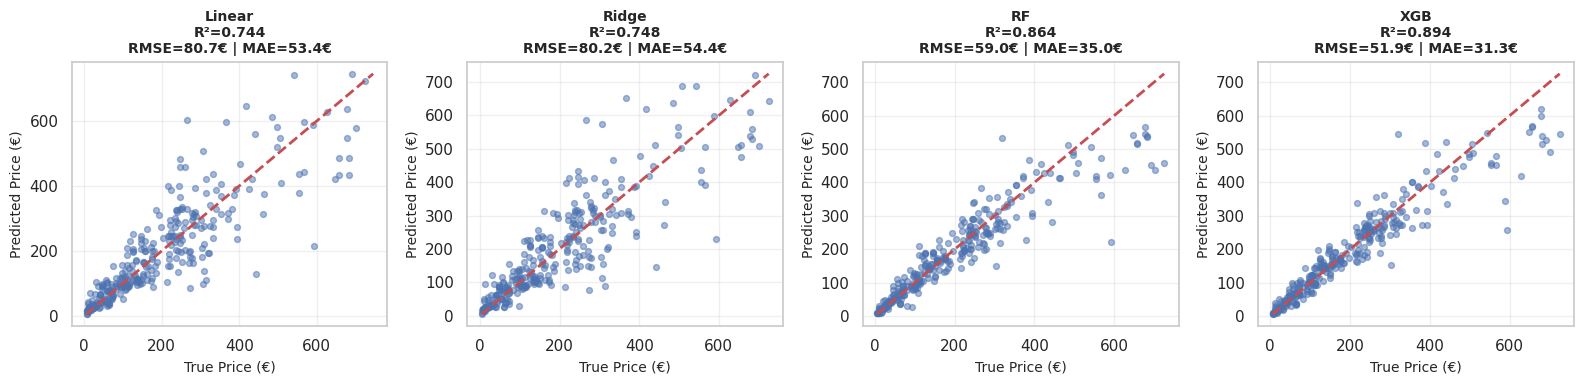

✅ Saved: ./results_log_hybrid/plots/model_comparison_predictions_val.png


In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
# Ensure output dir
os.makedirs("./results_log_hybrid/plots", exist_ok=True)

print("\n📈 Plot: Model comparison (Predicted vs Actual) — VALIDATION")

# Which models output log1p(price)?
# In your hybrid script, ALL models are trained on y_train_log -> so True for all.
MODEL_OUTPUT_IS_LOG = {
    "Linear": True,
    "Ridge": True,
    "RF": True,
    "XGB": True,
}

def predict_model_eur(model, X, is_log=True):
    yhat = model.predict(X)
    if is_log:
        yhat = np.expm1(yhat)
    yhat = np.clip(yhat, 0.0, None)  # no negative prices
    return yhat

fig = plt.figure(figsize=(16, 4))

names = list(models.keys())
for idx, name in enumerate(names):
    model = models[name]
    ax = plt.subplot(1, len(names), idx + 1)

    is_log = MODEL_OUTPUT_IS_LOG.get(name, True)
    y_pred = predict_model_eur(model, X_val_np, is_log=is_log)

    ax.scatter(y_val_eur, y_pred, alpha=0.5, s=18)

    # Perfect line
    min_val = min(np.min(y_val_eur), np.min(y_pred))
    max_val = max(np.max(y_val_eur), np.max(y_pred))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    # Metrics in €
    r2 = r2_score(y_val_eur, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_eur, y_pred))
    mae = mean_absolute_error(y_val_eur, y_pred)

    ax.set_xlabel("True Price (€)", fontsize=10)
    ax.set_ylabel("Predicted Price (€)", fontsize=10)
    ax.set_title(f"{name}\nR²={r2:.3f}\nRMSE={rmse:.1f}€ | MAE={mae:.1f}€",
                 fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
outpath = "./results_log_hybrid/plots/model_comparison_predictions_val.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"✅ Saved: {outpath}")



📈 Plot: Model comparison (Validation) — ZOOM price < 400€


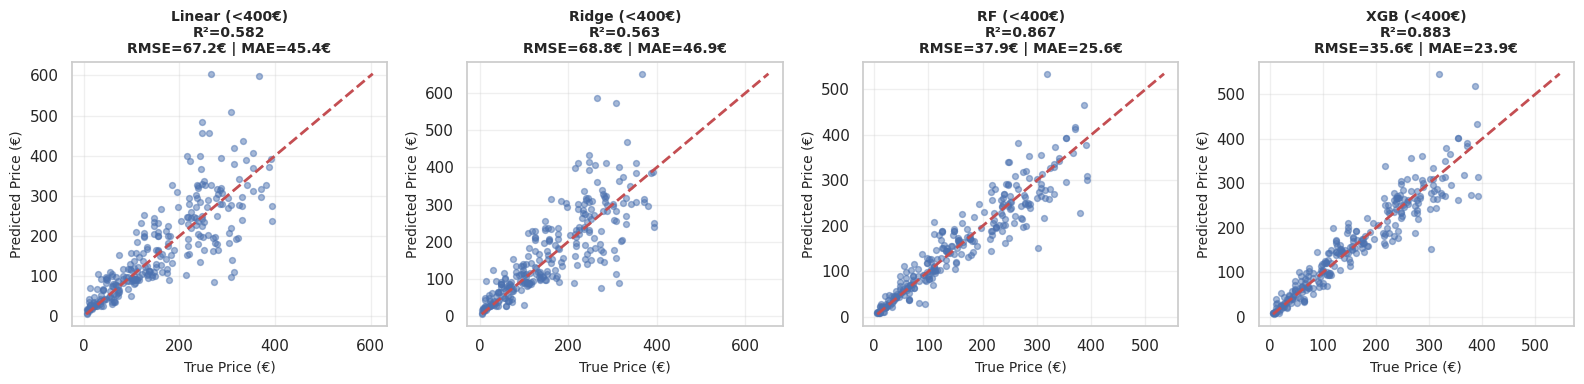

✅ Saved: ./results_log_hybrid/plots/model_comparison_predictions_val_zoom400.png


In [11]:
mask = y_val_eur < 400
print("\n📈 Plot: Model comparison (Validation) — ZOOM price < 400€")

fig = plt.figure(figsize=(16, 4))

for idx, name in enumerate(names):
    model = models[name]
    ax = plt.subplot(1, len(names), idx + 1)

    is_log = MODEL_OUTPUT_IS_LOG.get(name, True)
    y_pred = predict_model_eur(model, X_val_np, is_log=is_log)

    ax.scatter(y_val_eur[mask], y_pred[mask], alpha=0.5, s=18)

    min_val = min(np.min(y_val_eur[mask]), np.min(y_pred[mask]))
    max_val = max(np.max(y_val_eur[mask]), np.max(y_pred[mask]))
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

    r2 = r2_score(y_val_eur[mask], y_pred[mask])
    rmse = np.sqrt(mean_squared_error(y_val_eur[mask], y_pred[mask]))
    mae = mean_absolute_error(y_val_eur[mask], y_pred[mask])

    ax.set_xlabel("True Price (€)", fontsize=10)
    ax.set_ylabel("Predicted Price (€)", fontsize=10)
    ax.set_title(f"{name} (<400€)\nR²={r2:.3f}\nRMSE={rmse:.1f}€ | MAE={mae:.1f}€",
                 fontsize=10, fontweight="bold")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
outpath = "./results_log_hybrid/plots/model_comparison_predictions_val_zoom400.png"
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"✅ Saved: {outpath}")



📊 XGBoost: Top-10 Feature Importance (Speaker Price)


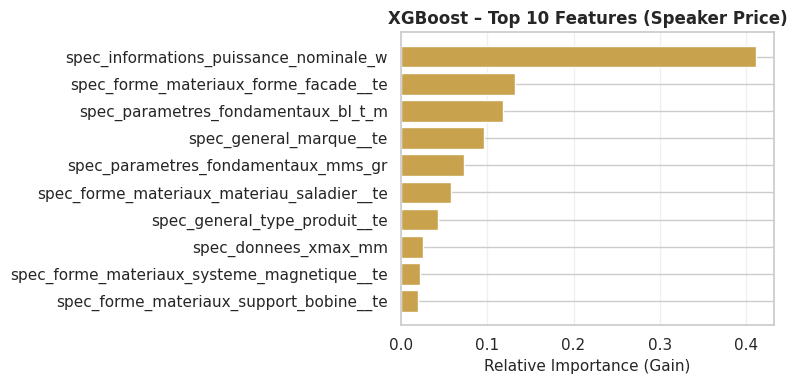

✅ Saved: ./results_log_hybrid/plots/xgb_top10_features.png

📋 Top-10 Features (decoded):
                                    feature  importance_norm
     spec_informations_puissance_nominale_w         0.411762
      spec_forme_materiaux_forme_facade__te         0.132047
        spec_parametres_fondamentaux_bl_t_m         0.118034
                    spec_general_marque__te         0.096770
        spec_parametres_fondamentaux_mms_gr         0.073428
 spec_forme_materiaux_materiau_saladier__te         0.057859
              spec_general_type_produit__te         0.043104
                       spec_donnees_xmax_mm         0.025500
spec_forme_materiaux_systeme_magnetique__te         0.021970
    spec_forme_materiaux_support_bobine__te         0.019526


In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

# ------------------------------------------------------------------
# XGBoost: Top-10 Feature Importance (GAIN) — decoded
# ------------------------------------------------------------------
print("\n📊 XGBoost: Top-10 Feature Importance (Speaker Price)")

os.makedirs("./results_log_hybrid/plots", exist_ok=True)

# Safety check (important)
assert len(feature_names) == X_train_np.shape[1], \
    "feature_names does not match XGBoost input shape"

# Get booster
booster = best_model.get_booster()

# Importance by gain
score = booster.get_score(importance_type="gain")

# Build DataFrame
imp_df = (
    pd.DataFrame({
        "feature_idx": score.keys(),      # f0, f1, ...
        "importance": score.values()
    })
    .sort_values("importance", ascending=False)
)

# Keep top 10
top10 = imp_df.head(10).copy()

# Decode XGBoost feature indices -> real feature names
top10["feature"] = top10["feature_idx"].apply(
    lambda f: feature_names[int(f[1:])]   # "f26" -> feature_names[26]
)

# Normalize for readability
top10["importance_norm"] = top10["importance"] / top10["importance"].sum()

# ------------------------------------------------------------------
# Plot with real feature names
# ------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.barh(
    top10["feature"][::-1],
    top10["importance_norm"][::-1],
    color="#c9a24d"
)

plt.xlabel("Relative Importance (Gain)", fontsize=11)
plt.title("XGBoost – Top 10 Features (Speaker Price)", fontsize=12, fontweight="bold")
plt.grid(axis="x", alpha=0.3)

outpath = "./results_log_hybrid/plots/xgb_top10_features.png"
plt.tight_layout()
plt.savefig(outpath, dpi=300, bbox_inches="tight")
plt.show()
plt.close()

print(f"✅ Saved: {outpath}")

# ------------------------------------------------------------------
# Print table (report-ready)
# ------------------------------------------------------------------
print("\n📋 Top-10 Features (decoded):")
print(
    top10[["feature", "importance_norm"]]
    .to_string(index=False)
)
